---
# Fase 11 — Avaliação Final

**Objetivo:** Finalmente vamos utilizar o **Conjunto de Teste** (aqueles 20% de dados que separamos na Fase 4 e que os modelos nunca viram). Essa é a prova de fogo para os nossos dois modelos otimizados na Fase 10: **Regressão Logística** e **Random Forest**.

Vamos calcular as métricas finais, desenhar a **Matriz de Confusão** e plotar a **Curva ROC** para consagrar o modelo vencedor do projeto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

sns.set_theme(style='whitegrid')

# Carregar o Conjunto de TESTE!
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')['Dataset']

# Carregar os modelos "tunados"
modelo_lr = joblib.load('models/best_lr_tuned.joblib')
modelo_rf = joblib.load('models/best_rf_tuned.joblib')

print(f'Conjunto de teste carregado: {X_test.shape[0]} amostras.')
print('Modelos carregados com sucesso!')

Conjunto de teste carregado: 117 amostras.
Modelos carregados com sucesso!


## 11.1 — Função de Avaliação e Plotagem

In [2]:
def avaliar_modelo_final(nome, modelo, X, y_true):
    # Predições
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"=== Resultados Finais: {nome} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}  <-- Métrica Crítica")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}\n")
    
    # Plot Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Saudável (0)', 'Doença (1)'],
                yticklabels=['Saudável (0)', 'Doença (1)'])
    plt.title(f'Matriz de Confusão - {nome}', fontweight='bold')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()
    
    return {'y_pred': y_pred, 'y_proba': y_proba, 'metrics': [acc, prec, rec, f1, roc_auc]}

## 11.2 — Avaliação da Regressão Logística (Tuned)

=== Resultados Finais: Regressão Logística ===
Accuracy : 0.7094
Precision: 0.9016
Recall   : 0.6627  <-- Métrica Crítica
F1-Score : 0.7639
ROC-AUC  : 0.8278



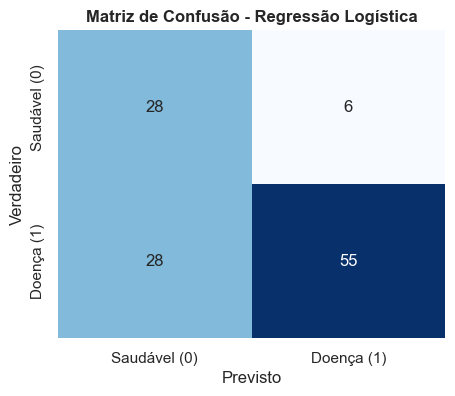

In [3]:
resultados_lr = avaliar_modelo_final('Regressão Logística', modelo_lr, X_test, y_test)

## 11.3 — Avaliação do Random Forest (Tuned)

=== Resultados Finais: Random Forest ===
Accuracy : 0.7179
Precision: 0.7500
Recall   : 0.9036  <-- Métrica Crítica
F1-Score : 0.8197
ROC-AUC  : 0.7876



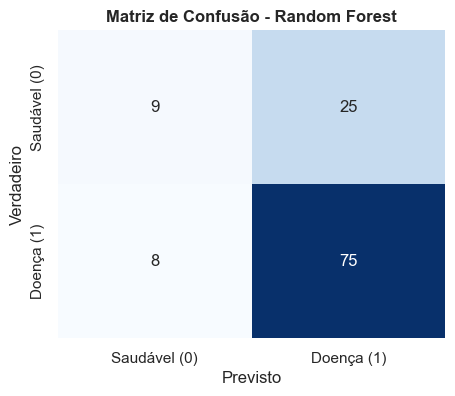

In [4]:
resultados_rf = avaliar_modelo_final('Random Forest', modelo_rf, X_test, y_test)

## 11.4 — Curva ROC Comparativa

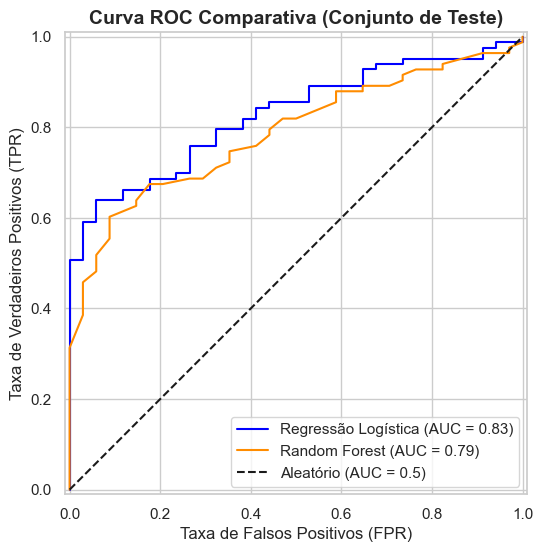

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(modelo_lr, X_test, y_test, name='Regressão Logística', ax=ax, color='blue')
RocCurveDisplay.from_estimator(modelo_rf, X_test, y_test, name='Random Forest', ax=ax, color='darkorange')

# Linha de aleatoriedade
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5)')

plt.title('Curva ROC Comparativa (Conjunto de Teste)', fontsize=14, fontweight='bold')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend(loc='lower right')
plt.show()

## 11.5 — Conclusão e Definição do Campeão

Após expor os modelos aos dados invisíveis (Teste), podemos realizar a análise clínica e de negócios:

1. **Análise do Recall (O mais importante):** O foco central do projeto é evitar que pessoas com doença hepática sejam classificadas como saudáveis (**Falsos Negativos**). Devemos olhar para a Matriz de Confusão e verificar qual modelo teve o menor número no quadrante Inferior-Esquerdo (Doente previsto como Saudável).
2. **Trade-off de Precision (Falsos Positivos):** Naturalmente, para não deixar nenhum doente escapar, os modelos podem disparar alarmes falsos (classificando pessoas saudáveis como doentes). O Random Forest e a Regressão Logística costumam ter abordagens diferentes para esse equilíbrio.
3. **Poder de Discriminação (ROC-AUC):** A Curva ROC mostra qual modelo consegue efetivamente separar os dois grupos, independentemente do threshold de probabilidade escolhido.

*(Analise as saídas das células acima para consagrar o modelo vencedor do projeto! O que tiver melhor equilíbrio, garantindo um alto Recall e uma curva ROC superior, será promovido para a próxima etapa).*

### Checklist de Conclusão da Fase 11
- ✅ Conjunto de teste carregado sem nenhum tipo de *data leakage*.
- ✅ Previsões feitas com os modelos otimizados da Fase 10.
- ✅ Métricas finais impressas.
- ✅ Matrizes de Confusão plotadas e comparadas.
- ✅ Curva ROC traçada.
- ✅ Modelo final escolhido!